<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/Rnn_vs_Ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.4 MB/s eta 0:00:00


In [2]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00


In [4]:
import re
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

In [5]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [74]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM

In [8]:
df = pd.read_csv("Book6.csv", encoding='latin1')

In [10]:
df.head(3)

,id,label,tweet
0,1,1,The first one is the best Rashid khan #AFGHANI...
1,2,1,East or west king Baber is Best #PAKISTAN
2,3,1,Best delivery was Adil Rashid bowled #AFGHANISTAN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      499 non-null    int64 
 1   label   499 non-null    int64 
 2   tweet   499 non-null    object
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [34]:
df['label'].value_counts()

,count
label,
1,254
0,245


Cleaning

In [14]:
df = df.drop(columns = {'id'})

In [15]:
def clean_text(text):
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'\S*@\S*\s?', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [w for w in text.split() if len(w) > 1]
    return " ".join(words)

In [16]:
df['tweet'] = df['tweet'].apply(clean_text)

In [19]:
df['tweet'][150]

'it is just match please do not abuse any nation after losing any team accept that lost and congrats the winner and winning side should also encourage the losing side make peace love'

In [22]:
stopwords = nltk.corpus.stopwords.words('english')
lemmatizer = WordNetLemmatizer()

In [20]:

def get_wordnet_pos(tag):
    """Convert NLTK POS tag to WordNet POS tag"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default fallback

In [21]:
def tokenize_lemmitize(text):

  # Word tokenization
  tokens = word_tokenize(text)

  pos_tags = nltk.pos_tag(tokens)

  lemmatized = []

  for word, tag in pos_tags:
    wn_tag = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_tag)

    if word not in stopwords and len(lemma) > 1:
      lemmatized.append(lemma)

  return lemmatized

In [24]:
df['tweet'] = df['tweet'].apply(tokenize_lemmitize)


TypeError: expected string or bytes-like object, got 'list'

In [26]:
df['tweet'][150]

['match',
 'please',
 'abuse',
 'nation',
 'lose',
 'team',
 'accept',
 'lose',
 'congrats',
 'winner',
 'win',
 'side',
 'also',
 'encourage',
 'losing',
 'side',
 'make',
 'peace',
 'love']

Embeddings ( word2Vec )

In [28]:
from gensim.models import Word2Vec

In [29]:
w2v_model = Word2Vec(
    sentences=df['tweet'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print(f"Word2Vec Vocabulary Size: {len(w2v_model.wv.key_to_index)}")

Word2Vec Vocabulary Size: 527


In [36]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['tweet'])

vocab_size = len(tokenizer.word_index) + 1
print(f"Tokenizer Vocabulary Size: {vocab_size}")

Tokenizer Vocabulary Size: 1178


In [37]:
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (1178, 100)


In [40]:
max_len = 200

X_seq = tokenizer.texts_to_sequences(df['tweet'])

X_padded = pad_sequences(X_seq, maxlen=max_len, padding='post')


X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, df['label'], test_size=0.3, random_state=42, stratify=df['label']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

In [44]:
X_padded[0]

array([ 75,  15,   6, 153, 154, 130,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

Simple Neural Network

In [46]:
def build_ann_model():

  model = Sequential()
  model.add(Dense(200, activation='relu', input_dim=max_len))
  model.add(Dropout(0.5))
  model.add(Dense(100, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(50, activation = 'relu'))
  model.add(Dense(1, activation='sigmoid'))


  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  model.summary()

  return model

In [47]:
simple_ann_model = build_ann_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,401 (255.47 KB)

 Trainable params: 65,401 (255.47 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
ann_history = simple_ann_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.5731 - loss: 1.4294 - val_accuracy: 0.5200 - val_loss: 1.1027
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5616 - loss: 1.3157 - val_accuracy: 0.5400 - val_loss: 1.0430
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5817 - loss: 1.2927 - val_accuracy: 0.5200 - val_loss: 1.0245
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6046 - loss: 1.2201 - val_accuracy: 0.5000 - val_loss: 1.0178
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5874 - loss: 1.2121 - val_accuracy: 0.5000 - val_loss: 0.9927
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5272 - loss: 1.2895 - val_accuracy: 0.5000 - val_loss: 0.9687
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5272 - loss: 1.4808 - val_accuracy: 0.5400 - val_loss: 0.9615
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5645 - loss: 1.3346 - val_accuracy: 0.

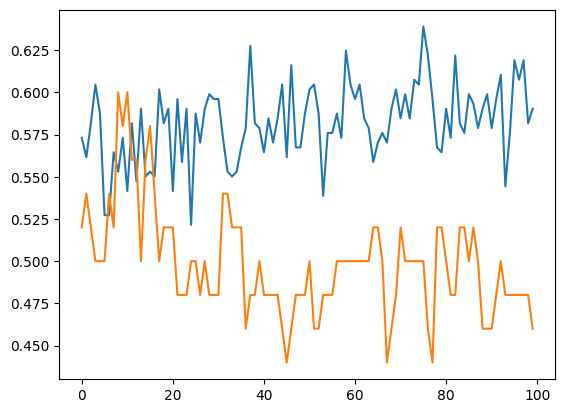

In [51]:
import matplotlib.pyplot as plt

plt.plot(ann_history.history['accuracy'])
plt.plot(ann_history.history['val_accuracy'])

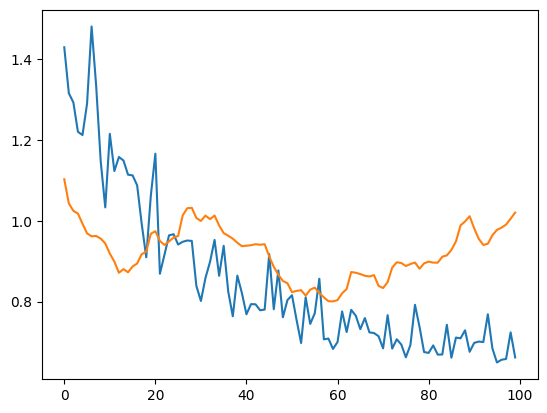

In [52]:
plt.plot(ann_history.history['loss'])
plt.plot(ann_history.history['val_loss'])

RNN

In [110]:
def build_rnn_model(mask):
  model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True,
        mask_zero= mask,
    ),
    SimpleRNN(128, dropout=0.4), # Increased dropout for regularization
    Dense(1, activation='sigmoid')
  ])

  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  model.summary()

  return model

In [111]:
rnn_model = build_rnn_model(False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │       117,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,800 (460.16 KB)

 Trainable params: 117,800 (460.16 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4785 - loss: 0.6977 - val_accuracy: 0.5400 - val_loss: 0.6950
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5415 - loss: 0.6926 - val_accuracy: 0.4800 - val_loss: 0.7018
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.4642 - loss: 0.7026 - val_accuracy: 0.4800 - val_loss: 0.6932
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5215 - loss: 0.6956 - val_accuracy: 0.4600 - val_loss: 0.6994
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.5215 - loss: 0.6964 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.4384 - loss: 0.6979 - val_accuracy: 0.5400 - val_loss: 0.6897
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4986 - loss: 0.6969 - val_accuracy: 0.4600 - val_loss: 0.6945
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4756 - loss: 0.6977 - val_accuracy: 0.5000 

### Model Evaluation

In [102]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# ANN Model Evaluation
print('ANN Model Evaluation:')
ann_pred_proba = simple_ann_model.predict(X_test)
ann_predictions = (ann_pred_proba > 0.5).astype(int)

cm_ann = confusion_matrix(y_test, ann_predictions)
precision_ann = precision_score(y_test, ann_predictions)
recall_ann = recall_score(y_test, ann_predictions)
f1_ann = f1_score(y_test, ann_predictions)

print('Confusion Matrix (ANN):')
print(cm_ann)
print(f'Precision (ANN): {precision_ann:.4f}')
print(f'Recall (ANN): {recall_ann:.4f}')
print(f'F1-Score (ANN): {f1_ann:.4f}')

ANN Model Evaluation:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Confusion Matrix (ANN):
[[ 6 43]
 [ 3 48]]
Precision (ANN): 0.5275
Recall (ANN): 0.9412
F1-Score (ANN): 0.6761


In [103]:
# RNN Model Evaluation
print('\nRNN Model Evaluation:')
rnn_pred_proba = rnn_model.predict(X_test)
rnn_predictions = (rnn_pred_proba > 0.5).astype(int)

cm_rnn = confusion_matrix(y_test, rnn_predictions)
precision_rnn = precision_score(y_test, rnn_predictions)
recall_rnn = recall_score(y_test, rnn_predictions)
f1_rnn = f1_score(y_test, rnn_predictions)

print('Confusion Matrix (RNN):')
print(cm_rnn)
print(f'Precision (RNN): {precision_rnn:.4f}')
print(f'Recall (RNN): {recall_rnn:.4f}')
print(f'F1-Score (RNN): {f1_rnn:.4f}')


RNN Model Evaluation:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Confusion Matrix (RNN):
[[44  5]
 [49  2]]
Precision (RNN): 0.2857
Recall (RNN): 0.0392
F1-Score (RNN): 0.0690


### ANN Model Training History

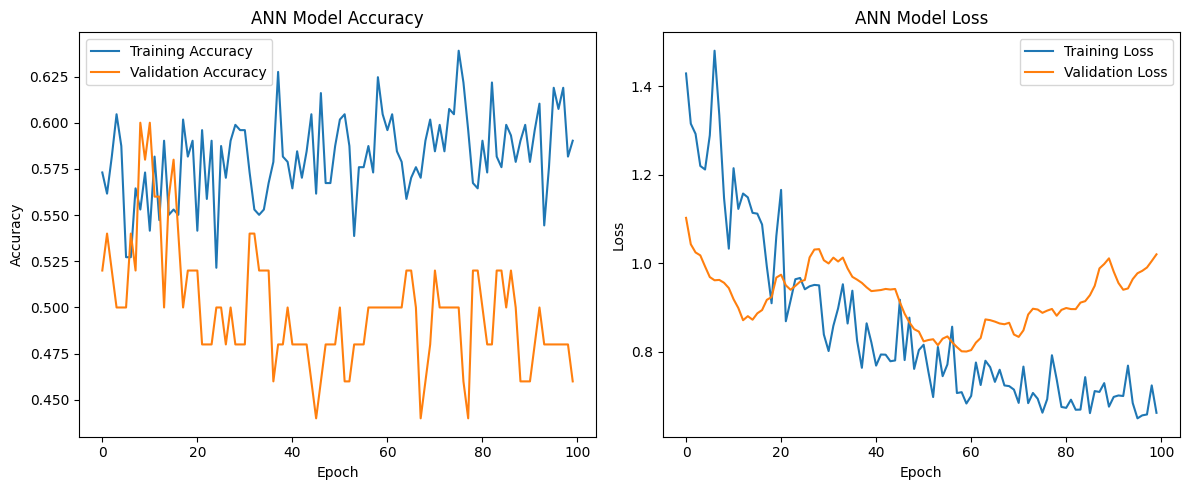

In [104]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='Training Loss')
plt.plot(ann_history.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### RNN Model Training History

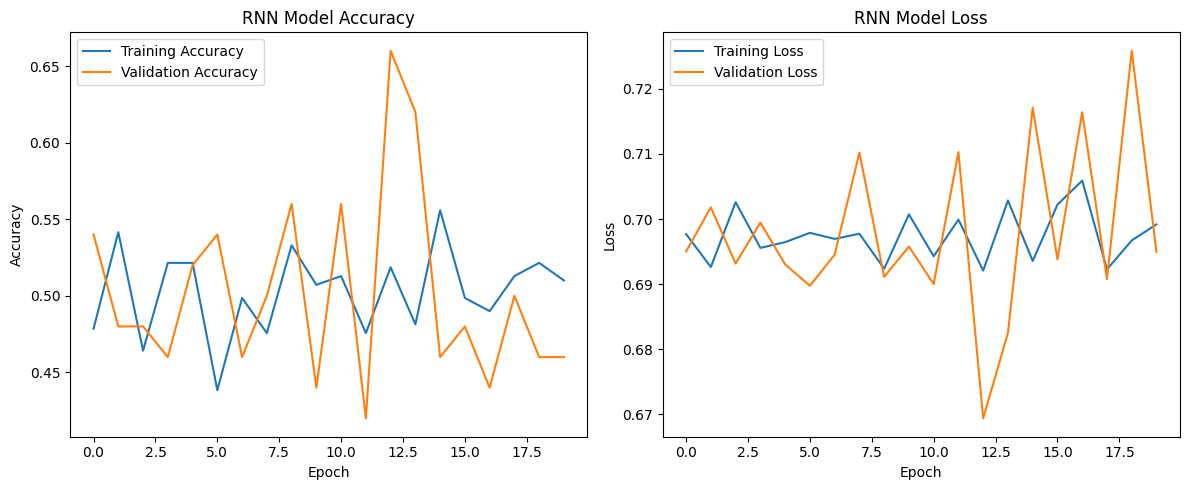

In [105]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [112]:
mask_model = build_rnn_model(True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │       117,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,800 (460.16 KB)

 Trainable params: 117,800 (460.16 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
mask_history = mask_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val
))

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.5358 - loss: 0.6867 - val_accuracy: 0.5800 - val_loss: 0.6837
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.8338 - loss: 0.5837 - val_accuracy: 0.6400 - val_loss: 0.6282
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.9456 - loss: 0.3725 - val_accuracy: 0.7400 - val_loss: 0.7598
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.9628 - loss: 0.2090 - val_accuracy: 0.7800 - val_loss: 0.7203
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9857 - loss: 0.1041 - val_accuracy: 0.7600 - val_loss: 0.8958
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.9943 - loss: 0.0660 - val_accuracy: 0.7600 - val_loss: 1.0446
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.9943 - loss: 0.0608 - val_accuracy: 0.7200 - val_loss: 1.2957
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.9713 - loss: 0.1846 - val_accuracy: 0.

The accuracy increased by 26% when we mask